In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 28})


def plot_results(dataset_choice, results_dir="../sam_results"):
    """
    Plot recall vs IoU threshold curves from CSV files that contain both overall and per‐class results.
    The CSV files are expected to have columns:
      dataset, sam_model, gridsize, iou_threshold, class, total_gt, detected_gt, recall
    All CSV files matching:
      results_{dataset_choice}_{sam_model}_{gridsize}_iou.csv
    are loaded and concatenated.

    Two sets of plots are generated:
      1. Overall recall (rows where class == "overall") in one plot.
      2. Per-class recall: separate plots for each gridsize, with curves for each class (for each model).
         Each plot contains data from a single gridsize.

    Curves are drawn with fixed colors for each model type and fixed linestyles for each gridsize.
    """
    # Find all CSV files matching the pattern.
    pattern = re.compile(
        rf"results_{dataset_choice}_(?P<sam_model>.+?)_(?P<grid>\d+)_iou\.csv"
    )
    csv_files = []
    for fname in os.listdir(results_dir):
        if pattern.match(fname):
            csv_files.append(os.path.join(results_dir, fname))

    if not csv_files:
        print(f"No CSV files found for dataset {dataset_choice} in {results_dir}.")
        return

    # Load and concatenate all CSV files.
    dfs = []
    for f in csv_files:
        try:
            df = pd.read_csv(f)
            dfs.append(df)
        except Exception as e:
            print(f"Error reading {f}: {e}")
    if not dfs:
        print("No valid CSV files loaded.")
        return
    df = pd.concat(dfs, ignore_index=True)

    # Define fixed color mapping for models and linestyles for grid sizes.
    model_colors = {
        "vit_h": "red",
        "vit_l": "blue",
        "vit_b": "green",
        "vit_tiny": "orange",
    }
    grid_linestyles = {
        16: "-",
        32: "--",
        64: ":",
        128: "-.",
    }

    model_markers = {
        "vit_h": "o",
        "vit_l": "s",
        "vit_b": "D",
        "vit_tiny": "*",
    }

    # Ensure gridsize is numeric.
    if df["gridsize"].dtype == object:
        df["gridsize"] = pd.to_numeric(df["gridsize"], errors="coerce")

    # ---- Overall Results Plot ----
    overall_df = df[df["class"] == "overall"]
    if overall_df.empty:
        print("No overall results found in CSV.")
    else:
        # plt.figure(figsize=(10, 6))
        plt.figure(figsize=(20, 20))

        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.gca().spines["left"].set_position(("outward", 1))  # Reduced from default
        plt.gca().spines["bottom"].set_position(("outward", 1))  # Reduced from default

        # Group by model and gridsize.
        for (model, grid), group in overall_df.groupby(["sam_model", "gridsize"]):
            group = group.sort_values("iou_threshold")
            plt.plot(
                group["iou_threshold"],
                group["recall"],
                marker=model_markers.get(
                    model, "o"
                ),  # Default to "o" if model not found
                label=f"{model} - Gridsize: {grid}",
                color=model_colors.get(model, None),
                linestyle=grid_linestyles.get(grid, "-"),
                markersize=20,
            )
        plt.xlabel("IoU Threshold")
        if dataset_choice == "DIOR":
            plt.ylabel("Recall")
        # plt.title(f"Overall Recall vs IoU Threshold for {dataset_choice}")
        plt.legend(fontsize="x-small", loc="best", ncol=2)
        plt.grid(True)
        plt.tight_layout()
        # plt.savefig(f"plots/overall_recall_{dataset_choice}.svg", bbox_inches='tight', pad_inches=0.01)
        plt.show()

    # ---- Per-Class Results Plot: One plot per gridsize ----
    # per_class_df = df[df['class'] != 'overall']
    # if per_class_df.empty:
    #     print("No per-class results found in CSV.")
    # else:
    #     grids = sorted(per_class_df['gridsize'].unique())
    #     for grid in grids:
    #         grid_df = per_class_df[per_class_df['gridsize'] == grid]
    #         plt.figure(figsize=(5, 3))
    #         # Group by class and model.
    #         for (cls, model), group in grid_df.groupby(['class', 'sam_model']):
    #             group = group.sort_values('iou_threshold')
    #             plt.plot(group['iou_threshold'], group['recall'], marker='o',
    #                      label=f"{cls}")
    #         plt.xlabel("IoU Threshold")
    #         plt.ylabel("Recall")
    #         plt.title(f"Per-Class Recall vs IoU Threshold for {dataset_choice} (grid {grid})")
    #         # plt.legend(fontsize='small', loc='best', ncol=2)
    #         plt.grid(True)
    #         plt.tight_layout()
    #         plt.savefig(f"plots/per_class_recall_{dataset_choice}_grid{grid}.svg")
    #         plt.show()


# Example usage:
dataset_choice = "WaffleHome"
plot_results(dataset_choice)

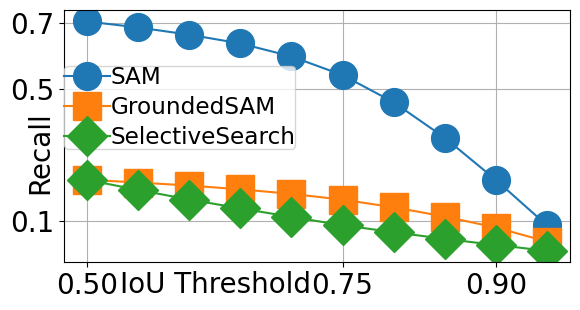

In [23]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator

plt.rcParams.update({"font.size": 20})

results_dir="../../sam_results"

results_files = os.listdir(results_dir)
results_files = [f for f in results_files if f.endswith(".csv")]

results = {}

for f in results_files:
    # print(f)
    # print(f.split("_"))
    if f.split("_")[6] in ["5", "21"]:
        continue
    if f.split("_")[4] == "64":
        continue
    df = pd.read_csv(os.path.join(results_dir, f))
    results[f.split("_")[5]] = df

markers = ["o", "s", "D", "*"]

sorted_keys = ['SAM', 'GroundedSAM', 'SelectiveSearch']
results = {k: results[k] for k in sorted_keys if k in results}

fig, ax = plt.subplots(figsize=(6.2, 3.5))
for i, (k, v) in enumerate(results.items()):
    v = v[v["class"] == "overall"]
    v = v.sort_values("iou_threshold")
    # print(k, v)
    if k == "SelectiveSearch":
        k = "SelectiveSearch"
    if k == "GroundedSAM":
        k = "GroundedSAM"
    ax.plot(
        v["iou_threshold"],
        v["recall"],
        marker=markers[i],
        label=f"{k}",
        linestyle="-",
        markersize=20,
    )
ax.set_xlabel("IoU Threshold", labelpad=4)
ax.xaxis.set_label_coords(0.3, -0.035)
ax.set_ylabel("Recall", labelpad=4)
ax.yaxis.set_label_coords(-0.02, 0.435)

legend = ax.legend(
    fontsize="small",
    loc=(0, 0.45),               # put legend below its anchor point
    # bbox_to_anchor=(0.5, 1.02),       # (x, y) in axes fraction coordinates
    # ncol=3,
    # borderaxespad=0,    # padding between axes and legend border
    borderpad=0,      # padding between legend border and contents
    labelspacing=0.3,   # vertical space between entries
    handletextpad=0,  # space between marker and text
    columnspacing=0   # space between columns
)

ax.xaxis.set_major_locator(FixedLocator([0.50, 0.75, 0.9]))
ax.yaxis.set_major_locator(FixedLocator([0.1, 0.5, 0.7]))

ax.grid(True)
plt.tight_layout()
plt.savefig(
    f"../../plots/overall_recall.png", bbox_inches="tight", pad_inches=0.01
)
plt.show()



In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 20})

results_dir="../../sam_results"

results_files = os.listdir(results_dir)
results_files = [f for f in results_files if f.endswith(".csv")]

results = {}

for f in results_files:
    print(f)
    print(f.split("_"))
    if f.split("_")[4] == "64":
        continue
    if f.split("_")[5] != "SAM":
        continue
    df = pd.read_csv(os.path.join(results_dir, f))

    results[f.split("_")[5] + "_" + f.split("_")[6]] = df

markers = ["o", "s", "D", "*"]

fig, ax = plt.subplots(figsize=(10, 6))
# tab10
colormap = plt.get_cmap("tab10")
order_keys = ["SAM_0", "SAM_5", "SAM_21"]

for i, key in enumerate(order_keys):
    v = results[key]
    v = v[v["class"] == "overall"]
    v = v.sort_values("iou_threshold")

    # print IoU@75 value
    print(key, v["recall"].iloc[5])
    if key == "SAM_5":
        name = "$k=5$"
    if key == "SAM_21":
        name = "$k=21$"
    if key == "SAM_0":
        name = "No Gaussian"
    ax.plot(
        v["iou_threshold"],
        v["recall"],
        marker=markers[i],
        label=name,
        linestyle="-",
        markersize=20,
        color=colormap(i),
    )
ax.set_xlabel("IoU Threshold")
ax.set_ylabel("Recall")
legend = ax.legend(
    fontsize="medium",
    loc="lower center",               # put legend below its anchor point
    bbox_to_anchor=(0.5, 1.02),       # (x, y) in axes fraction coordinates
    ncol=3,
    borderaxespad=0                   # remove any internal padding
)

ax.grid(True)
plt.tight_layout()
plt.savefig(
    f"../../plots/blur_recall.png", bbox_inches="tight", pad_inches=0.01
)
plt.show()



In [ ]:
for i in [0, 5, 21]:
    print(0.3*((i-1)*0.5 - 1) + 0.8)

In [11]:
import re
import xml.etree.ElementTree as ET
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Tuple

Number = float
Point  = Tuple[Number, Number]          # (x, y) in axes coordinates
Curves = Dict[str, List[Point]]         # { "line2d_1": [(x1, y1), ...], ... }

SVG_NS = {"svg": "http://www.w3.org/2000/svg"}

def _axes_border_bbox(axes_g: ET.Element) -> Tuple[Number, Number, Number, Number]:
    """
    Return the bounding rectangle of an Axes group in SVG pixel units:
    (left, right, top, bottom)
    """
    border = axes_g.find(".//svg:path[starts-with(@id,'patch_')]", SVG_NS)
    if border is None:
        raise RuntimeError("Axes border <path> not found")
    # The 'd' string is 'M x0 y0 L x1 y1 L x2 y2 L x3 y3 Z'
    nums = list(map(float, re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", border.attrib["d"])))
    if len(nums) < 8:
        raise RuntimeError("Cannot parse border path")
    left,  bottom = nums[0], nums[1]
    right, bottom = nums[2], nums[3]     # bottom stays the same
    right, top    = nums[4], nums[5]
    left,  top    = nums[6], nums[7]
    return left, right, top, bottom

def extract_marker_positions(svg_file: str, axes_id: str = "axes_1") -> Curves:
    """
    Parameters
    ----------
    svg_file : str or Path
        Path to the SVG created by Matplotlib.
    axes_id : str, optional
        Which <g id="axes_*"> to read (default "axes_1").
    
    Returns
    -------
    Curves
        Dictionary mapping each curve group id ("line2d_1", …) to a list of
        (x, y) marker centres expressed in Axes coordinates.
    """
    svg_file = Path(svg_file)
    tree = ET.parse(svg_file)
    root = tree.getroot()

    axes_g = root.find(f".//svg:g[@id='{axes_id}']", SVG_NS)
    if axes_g is None:
        raise RuntimeError(f"Group id='{axes_id}' not found")

    left, right, top, bottom = _axes_border_bbox(axes_g)
    width  = right - left
    height = bottom - top

    markers: Curves = defaultdict(list)

    line_groups = axes_g.findall("./svg:g[starts-with(@id,'line2d_')]", SVG_NS)
    for lg in line_groups:
        gid = lg.attrib["id"]
        for use in lg.findall(".//svg:use", SVG_NS):
            # Matplotlib stores marker centres in attributes x and y
            x_px = float(use.attrib["x"])
            y_px = float(use.attrib["y"])
            # Convert to axes fraction
            x_ax = (x_px - left) / width
            y_ax = 1.0 - (y_px - top) / height     # invert y
            markers[gid].append((x_ax, y_ax))

    return dict(markers)

# ----------------------------------------------------------------------
# Example
# ----------------------------------------------------------------------
if __name__ == "__main__":
    svg_file = "../../overall_recall_DOTAv2.svg"               # your Matplotlib SVG file
    positions = extract_marker_positions(svg_file)
    for curve, pts in positions.items():
        print(f"{curve}: {len(pts)} marker(s)")
        for p in pts:
            print(f"    {p}")


SyntaxError: invalid predicate (<string>)

results_DIOR_vit_h_64_SAM_iou.csv
['results', 'DIOR', 'vit', 'h', '64', 'SAM', 'iou.csv']
results_DIOR_vit_h_32_SAM_5_iou.csv
['results', 'DIOR', 'vit', 'h', '32', 'SAM', '5', 'iou.csv']
results_SARDet_vit_h_32_SAM_0_iou.csv
['results', 'SARDet', 'vit', 'h', '32', 'SAM', '0', 'iou.csv']
results_DIOR_vit_h_32_GroundedSAM_iou.csv
['results', 'DIOR', 'vit', 'h', '32', 'GroundedSAM', 'iou.csv']
results_DIOR_vit_h_32_SAM_0_iou.csv
['results', 'DIOR', 'vit', 'h', '32', 'SAM', '0', 'iou.csv']
results_DIOR_vit_h_32_SAM_21_iou.csv
['results', 'DIOR', 'vit', 'h', '32', 'SAM', '21', 'iou.csv']
results_DIOR_vit_h_32_SelectiveSearch_iou.csv
['results', 'DIOR', 'vit', 'h', '32', 'SelectiveSearch', 'iou.csv']
dict_keys(['SAM_0'])


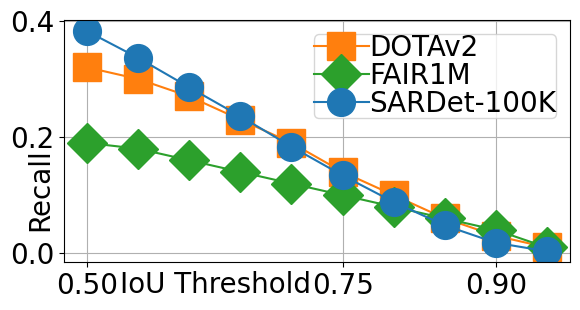

In [14]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from xml.etree import ElementTree as ET
from pathlib import Path
from typing import Dict, List, Tuple
import numpy as np
from matplotlib.ticker import MultipleLocator, FixedLocator
from lxml import etree
from svgpathtools import parse_path
from collections import defaultdict

svg_file = "../../overall_recall_DOTAv2.svg"

plt.rcParams.update({"font.size": 20})

results_dir="../../sam_results"

results_files = os.listdir(results_dir)
results_files = [f for f in results_files if f.endswith(".csv")]

results = {}

for f in results_files:
    print(f)
    print(f.split("_"))
    if "SARDet" not in f:
        continue
    df = pd.read_csv(os.path.join(results_dir, f))

    results[f.split("_")[5] + "_" + f.split("_")[6]] = df

markers = ["o", "s", "D", "*"]

fig, ax = plt.subplots(figsize=(6.2, 3.5))
# tab10
colormap = plt.get_cmap("tab10")
print(results.keys())
order_keys = ["SAM_0"]

dotav2_results = [0.32, 0.3, 0.27, 0.23, 0.19, 0.14, 0.1, 0.06, 0.03, 0.01]
fair1m_results = [0.19, 0.18, 0.16, 0.14, 0.12, 0.1, 0.08, 0.06, 0.04, 0.01]

# plot dotav2 results
ax.plot(
    [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95],
    dotav2_results,
    marker="s",
    label="DOTAv2",
    linestyle="-",
    markersize=20,
    color=colormap(1),
)

# plot FAIR1M results
ax.plot(
    [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95],
    fair1m_results,
    marker="D",
    label="FAIR1M",
    linestyle="-",
    markersize=20,
    color=colormap(2),
)

for i, key in enumerate(order_keys):
    v = results[key]
    v = v[v["class"] == "overall"]
    v = v.sort_values("iou_threshold")

    if key == "SAM_5":
        name = "$k=5$"
    if key == "SAM_21":
        name = "$k=21$"
    if key == "SAM_0":
        name = "SARDet-100K"
    ax.plot(
        v["iou_threshold"],
        v["recall"],
        marker=markers[i],
        label=name,
        linestyle="-",
        markersize=20,
        color=colormap(i),
    )



ax.set_xlabel("IoU Threshold", labelpad=3)
ax.xaxis.set_label_coords(0.3, -0.035)
ax.set_ylabel("Recall", labelpad=4)
ax.yaxis.set_label_coords(-0.02, 0.3)

legend = ax.legend(
    fontsize="medium",
    # loc="lower center",               # put legend below its anchor point
    # bbox_to_anchor=(0.5, 1.02),       # (x, y) in axes fraction coordinates
    # ncol=3,
    # borderaxespad=0,    # padding between axes and legend border
    borderpad=0,      # padding between legend border and contents
    labelspacing=0,   # vertical space between entries
    handletextpad=0,  # space between marker and text
    columnspacing=0   # space between columns
)

ax.xaxis.set_major_locator(FixedLocator([0.50, 0.75, 0.9]))

ax.grid(True)
plt.tight_layout()
plt.savefig(
    f"../../plots/sardet_recall.png", bbox_inches="tight", pad_inches=0.01
)
plt.show()

